In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/sebastiangutierrezbernal/Desktop/Personal/Quantum Research/info-patterns-repo


In [2]:
from src.parameters import (SPHERE_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, DEFAULT_FARFIELD_PARAMS, FAST_FARFIELD_PARAMS, 
                            DEFAULT_GAUSSIAN_FIELD_PARAMS, DEFAULT_DYADS_PARAMS, DEFAULT_COM_DISPLACEMENT_NM, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_RESULTS_DIR, 
                            DEFAULT_SAVE_TYPE, DEFAULT_2D_PLANES, DEFAULT_2D_NORMALIZE, DEFAULT_2D_FILL)

from src.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material)

from src.light_matter_interaction_simulation import (incident_field, field_propagation, simulation_from_geometry, scattered_farfield_from_simulation, com_scattered_farfield)

from src.information_patterns_simulation import (info_patterns_from_scattered_field)

from src.specific_incident_fields import (filling_factor, richards_wolf_gaussian_efield)

from src.plots import (set_plot_style, plot3d_info_patterns, plot2d_info_patterns)

set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "com_sphere_results"

In [3]:
geometry = nanoparticle_geometry(**SPHERE_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)

In [4]:
NA = 0.75
wavelength_nm = DEFAULT_WAVELENGTH_NM
farfield_params = DEFAULT_FARFIELD_PARAMS
Ntheta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
field_index = farfield_params["field_index"]
r = farfield_params["r"]
disp_nm = DEFAULT_COM_DISPLACEMENT_NM

gamma = filling_factor(w_0=4000.0, f=2000.0, NA=NA, n_medium=1.0)
richards_wolf_field_params = {"field_generator": richards_wolf_gaussian_efield, "wavelengths": [wavelength_nm], "n_medium": 1.0, "NA": NA, "gamma": gamma, "f": None, "w_0": None, 
                              "E0": 1.0, "Ntheta": 30, "Nphi": 60, "polarization_state": (1, 0, 0, 0), "xSpot": 0.0, "ySpot": 0.0, "zSpot": 0.0}

efield = incident_field(**richards_wolf_field_params)
dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 1462.0ms, inv.: 219.7ms, repropa.: 55.9ms (1 field configs), tot: 1737.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 38.9ms, inv.: 355.2ms, repropa.: 68.1ms (1 field configs), tot: 462.4ms


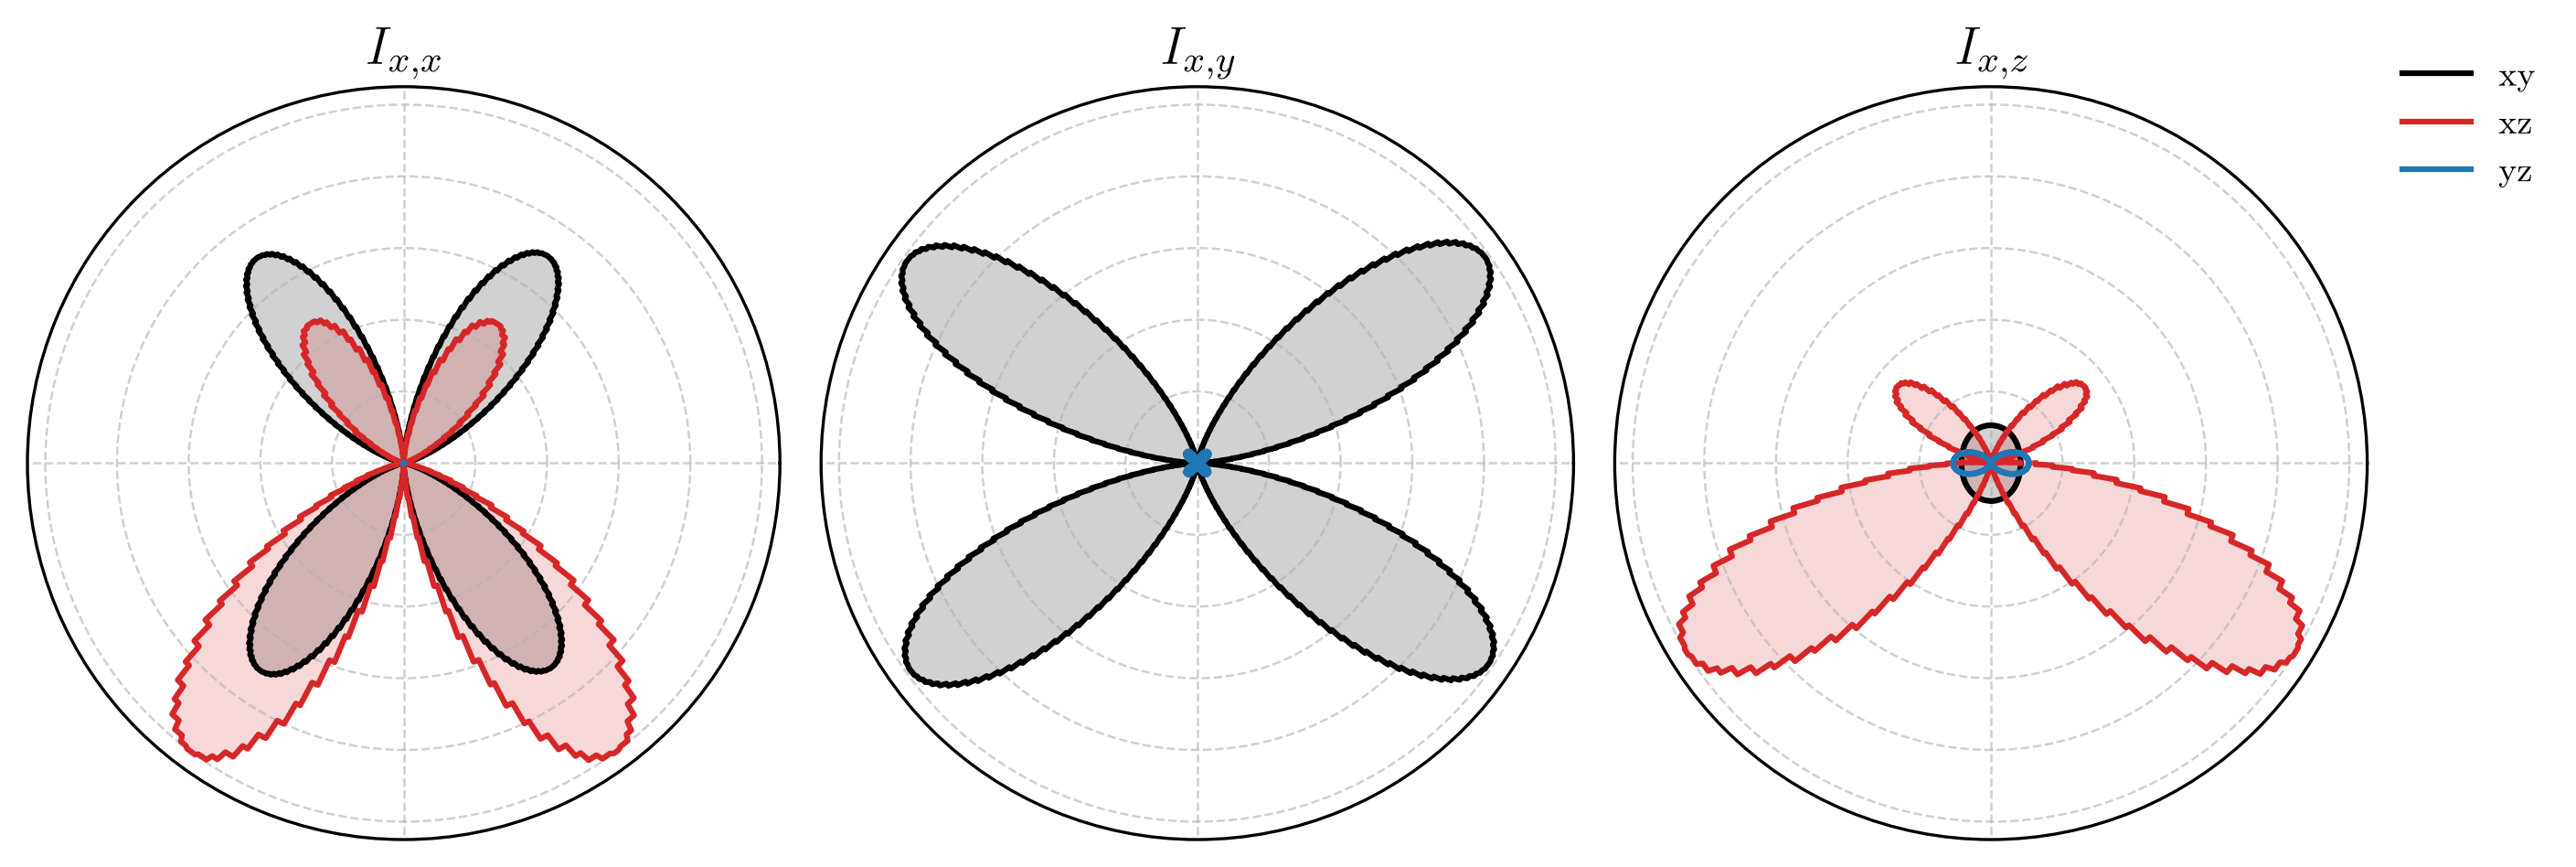

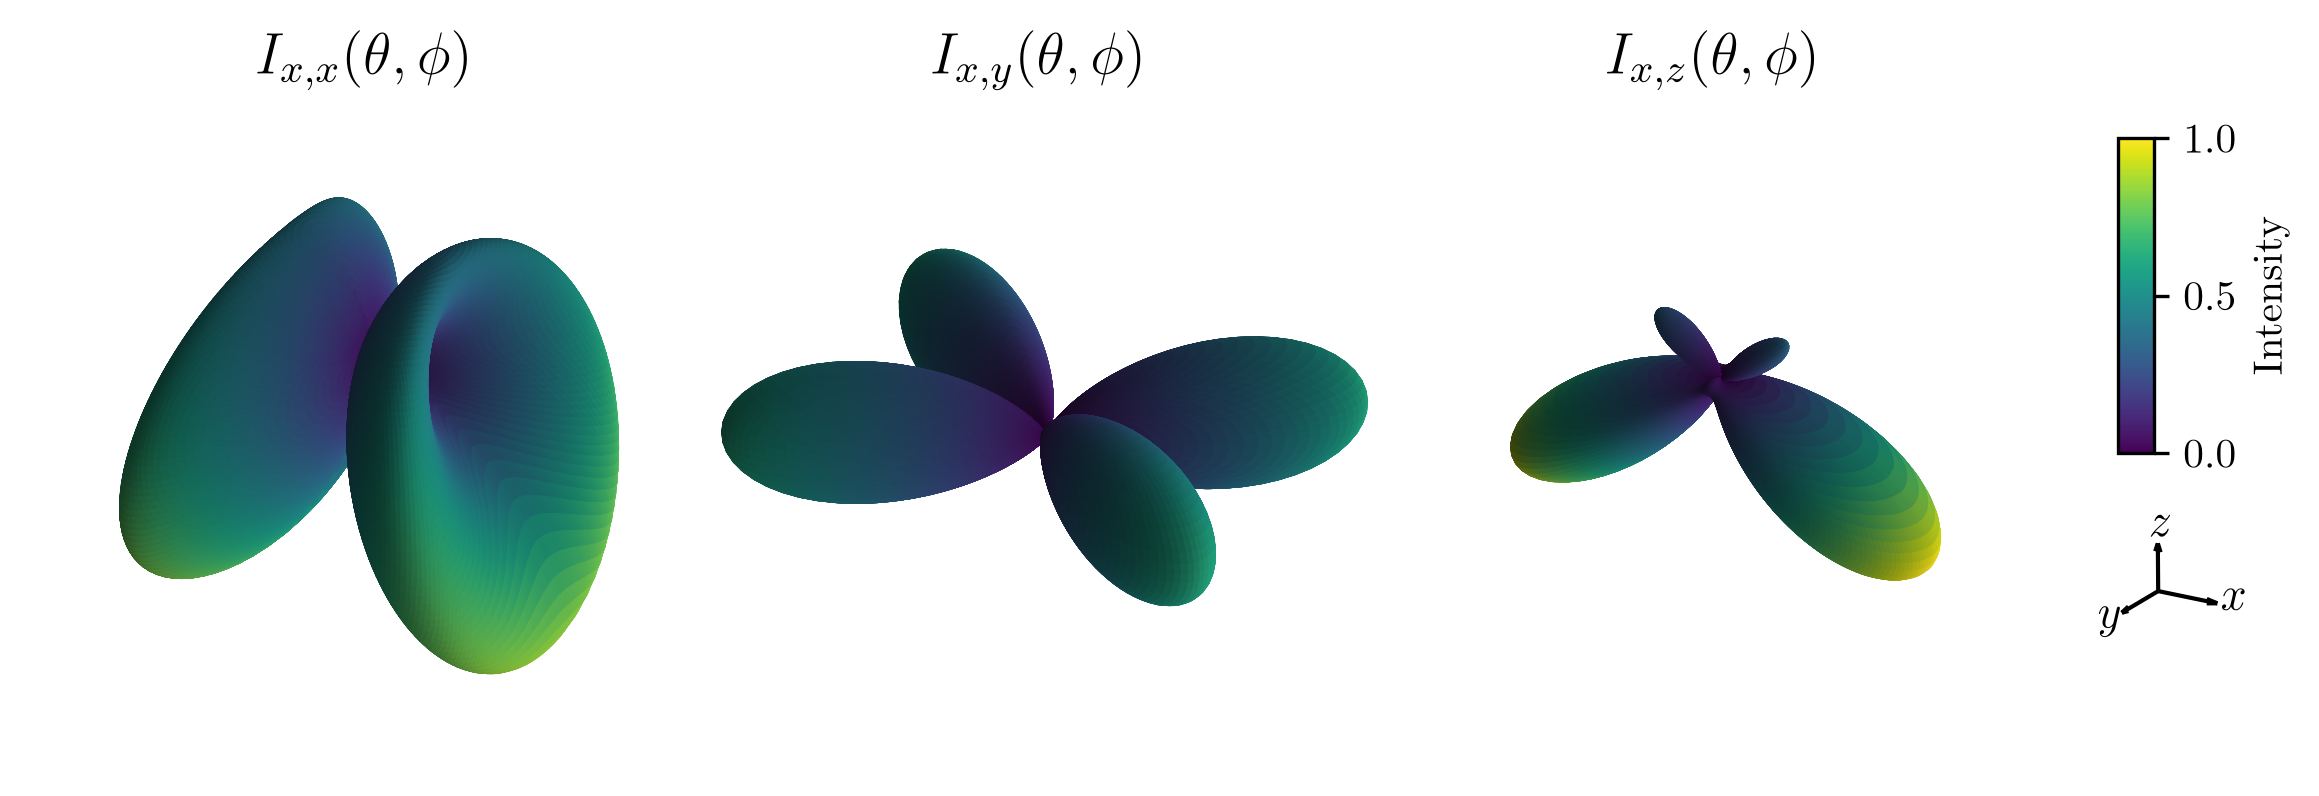

In [5]:
E_plus_x, E_minus_x, dE_x = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=0, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_x_total, I_x_Ex, I_x_Ey, I_x_Ez = info_patterns_from_scattered_field(dE=dE_x, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_x_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, 
                     scale_list=[0.4, 0.32, 0.36], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_x_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 123.8ms, inv.: 402.9ms, repropa.: 58.1ms (1 field configs), tot: 585.0ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 49.8ms, inv.: 304.5ms, repropa.: 82.9ms (1 field configs), tot: 438.6ms


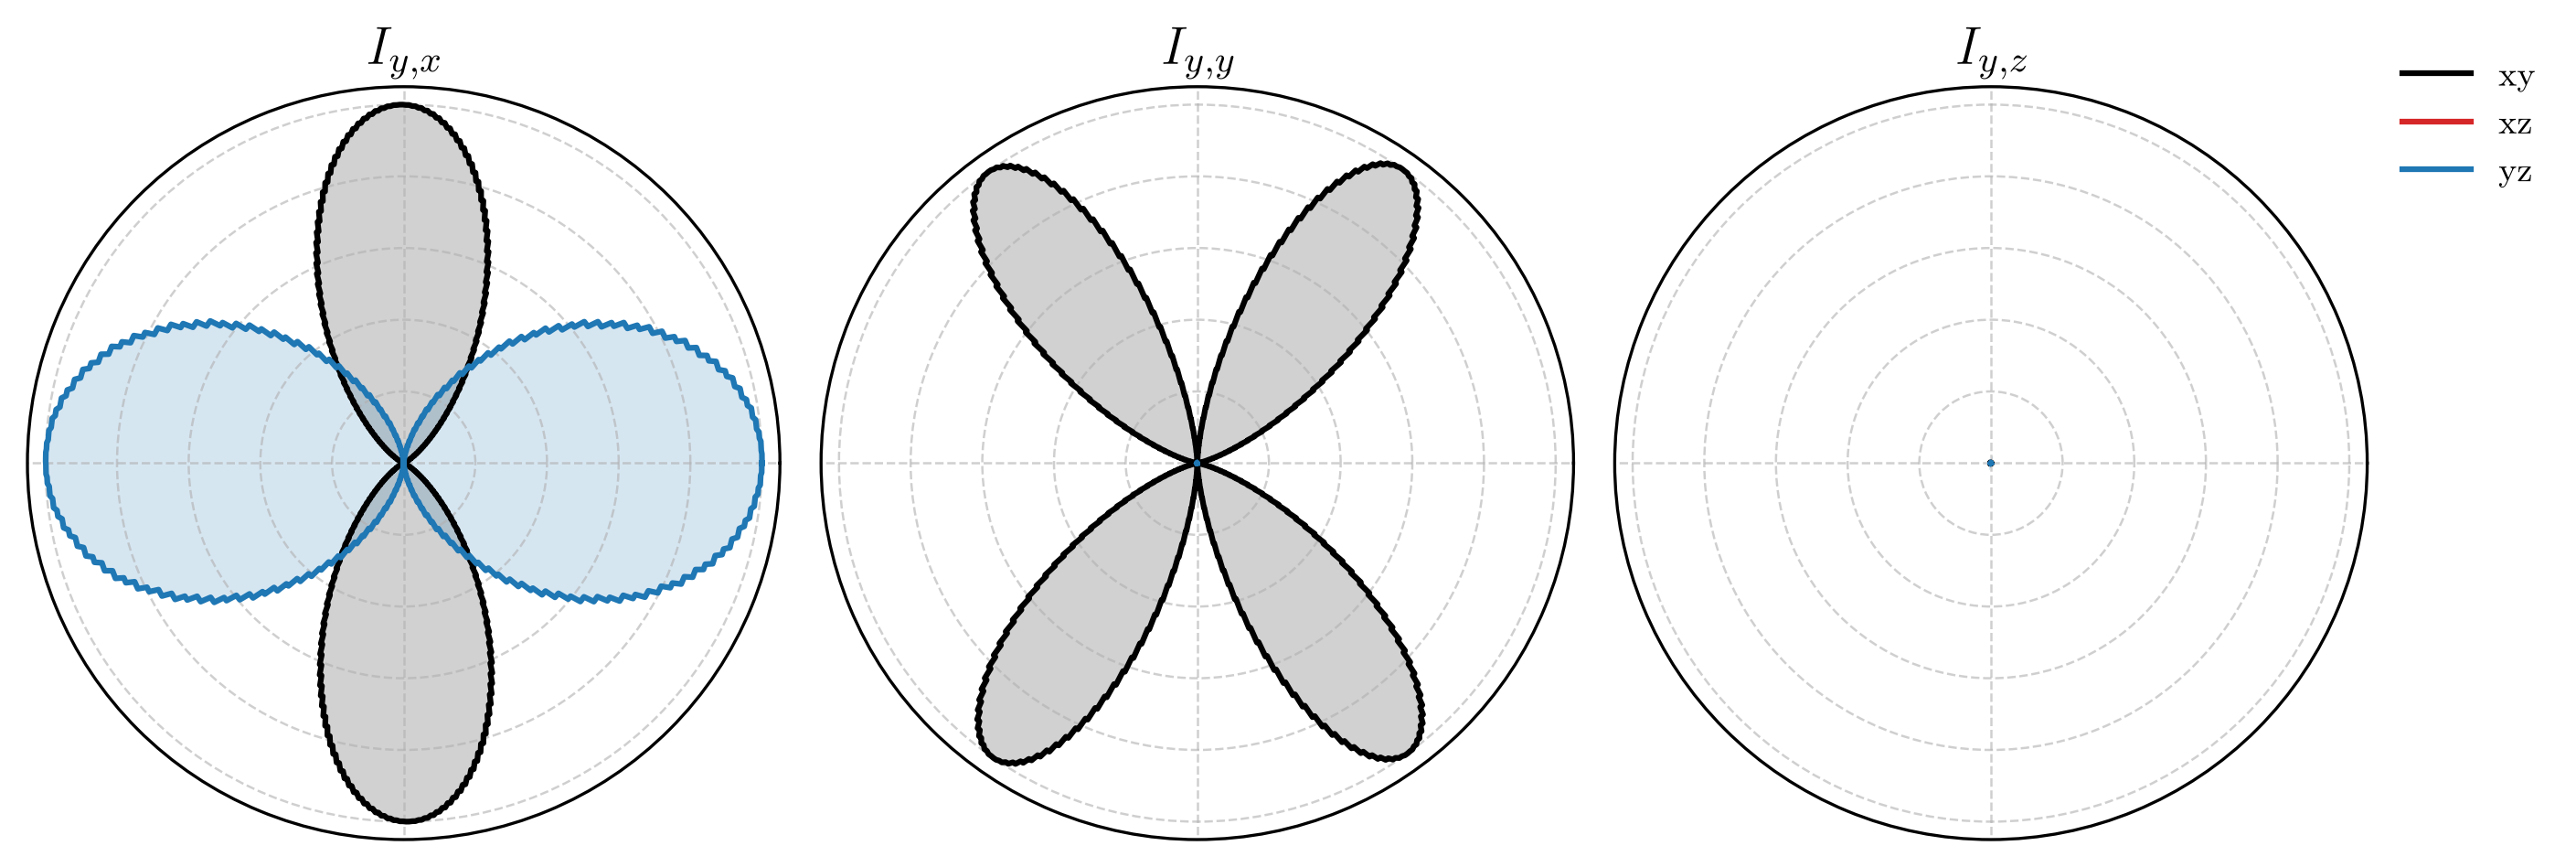

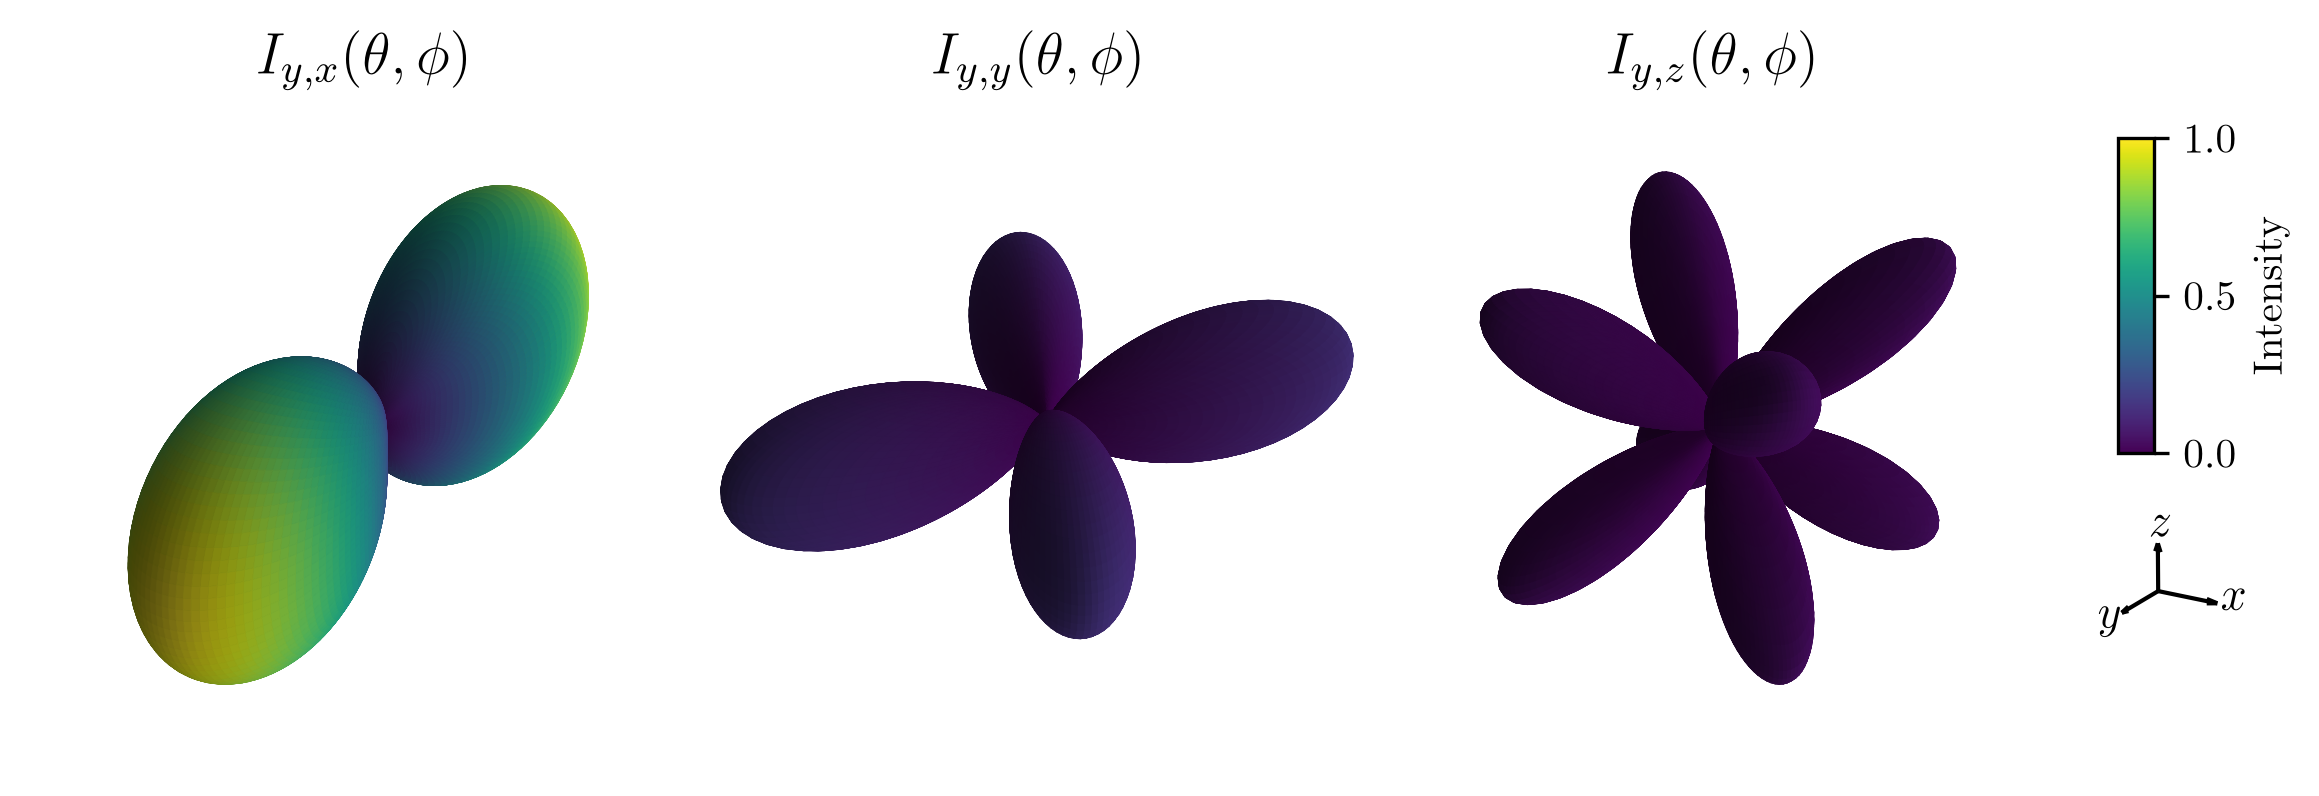

In [6]:
E_plus_y, E_minus_y, dE_y = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=1, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_y_total, I_y_Ex, I_y_Ey, I_y_Ez = info_patterns_from_scattered_field(dE=dE_y, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_y_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, 
                     scale_list=[0.22, 0.3, 0.48], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_y_3d", results_dir=results_dir)

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 44.7ms, inv.: 222.3ms, repropa.: 55.9ms (1 field configs), tot: 323.1ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 49.7ms, inv.: 389.0ms, repropa.: 57.3ms (1 field configs), tot: 496.3ms


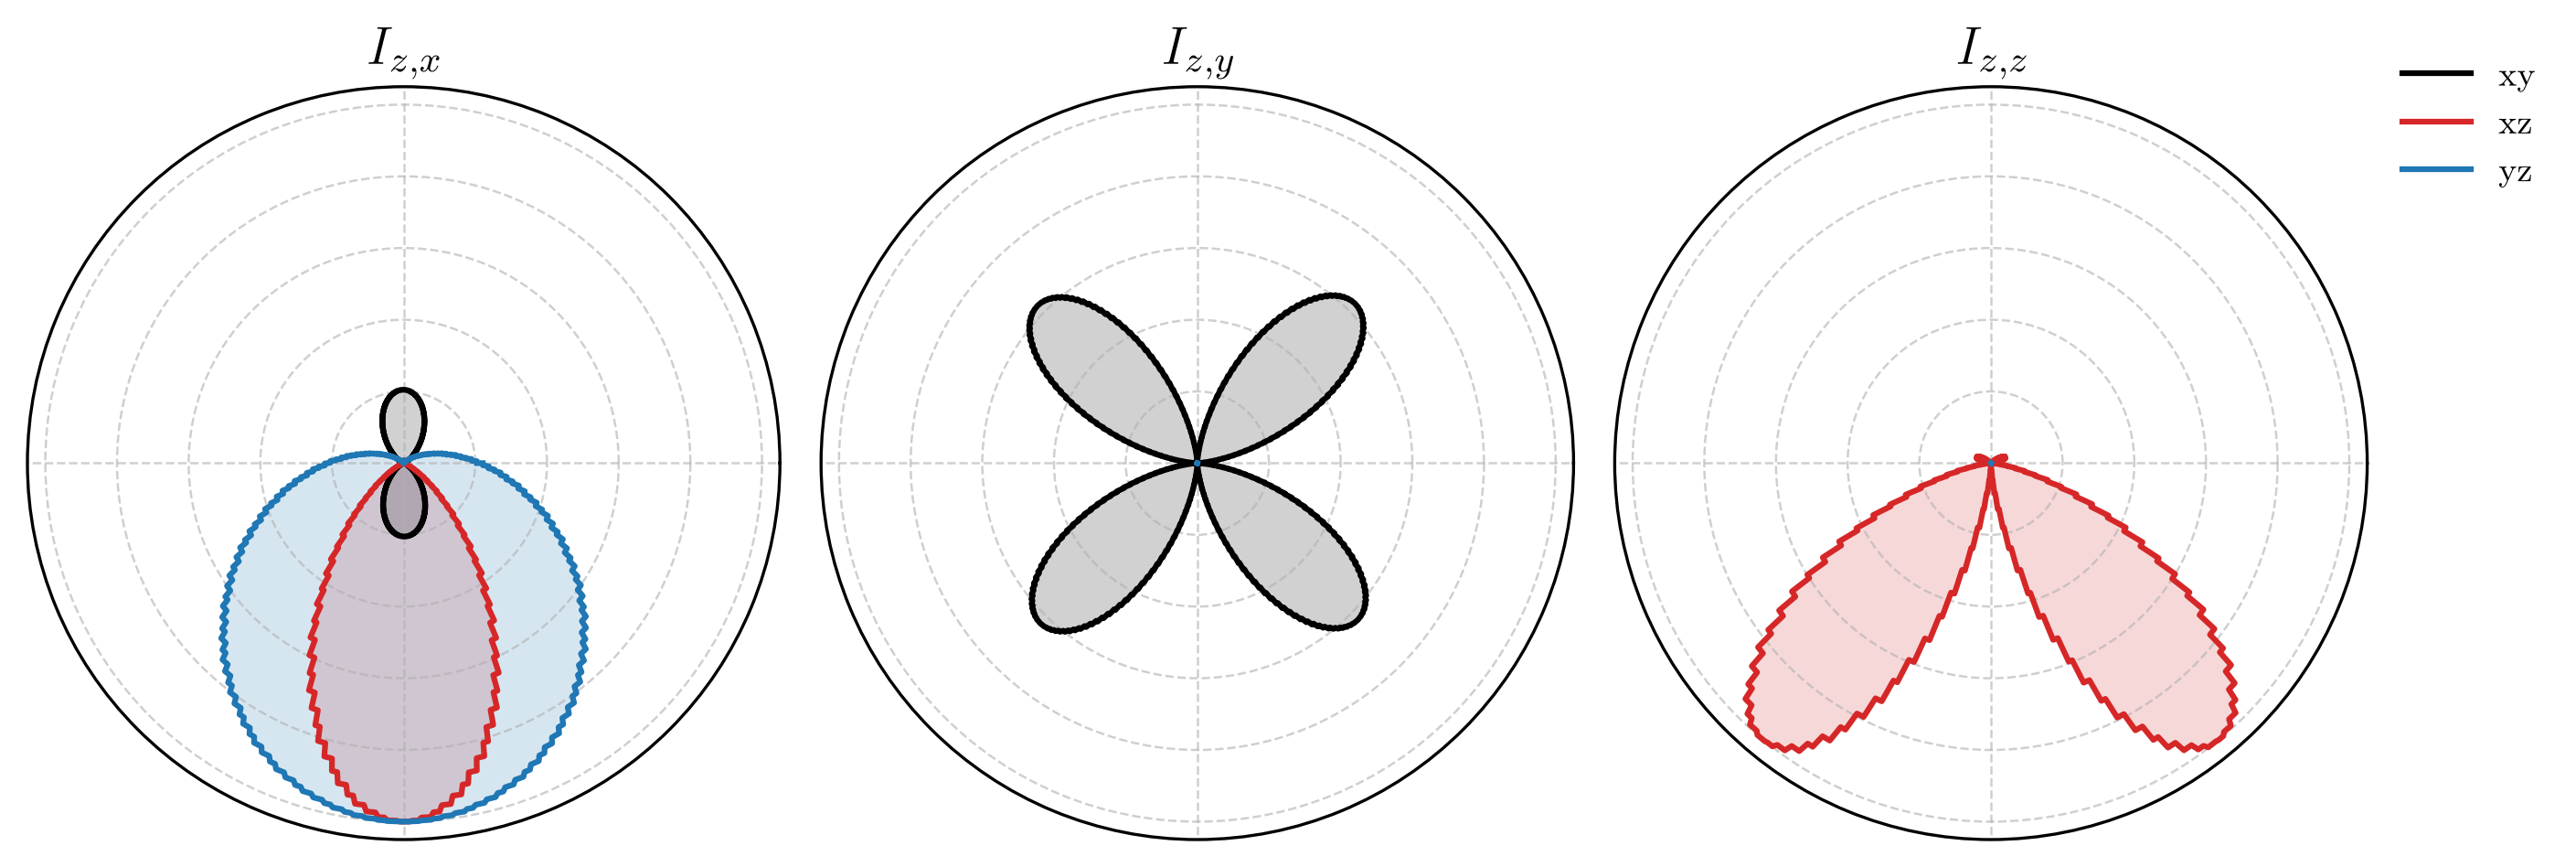

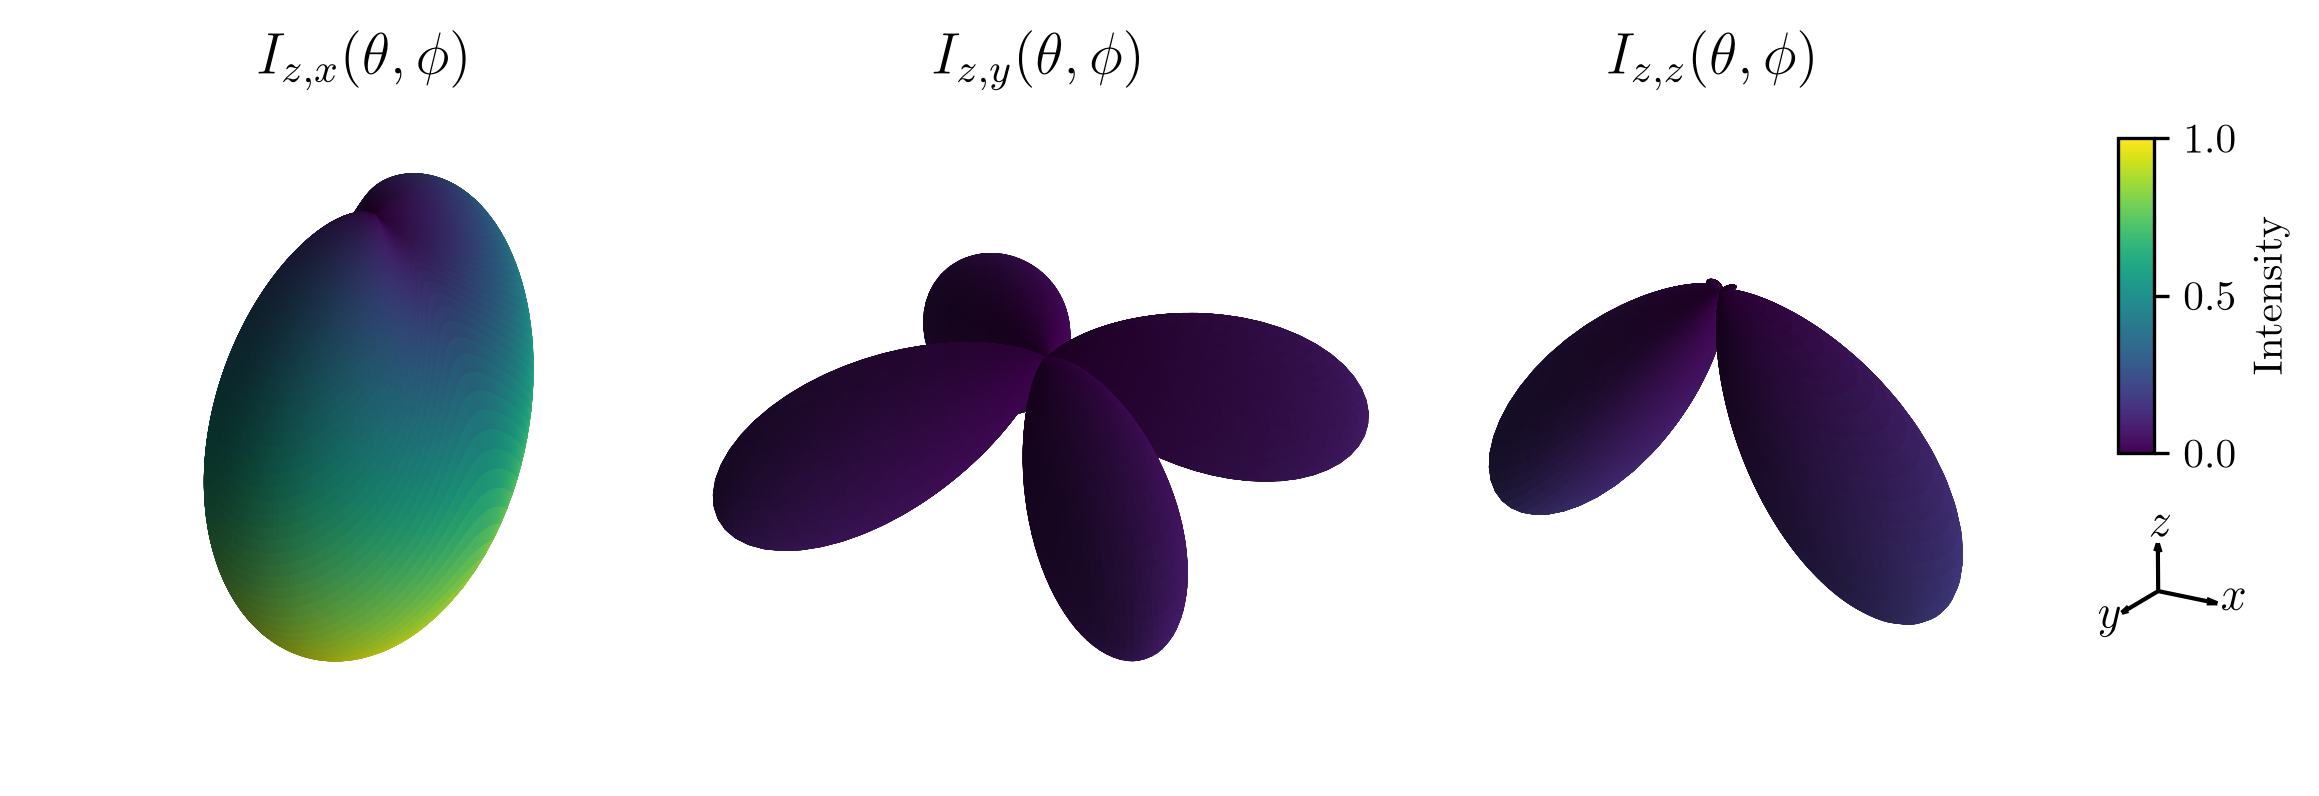

In [7]:
E_plus_z, E_minus_z, dE_z = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=efield, dyads=dyads, axis_index=2, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_z_total, I_z_Ex, I_z_Ey, I_z_Ez = info_patterns_from_scattered_field(dE=dE_z, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_z_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, 
                     scale_list=[0.36, 0.34, 0.33], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_z_3d", results_dir=results_dir)

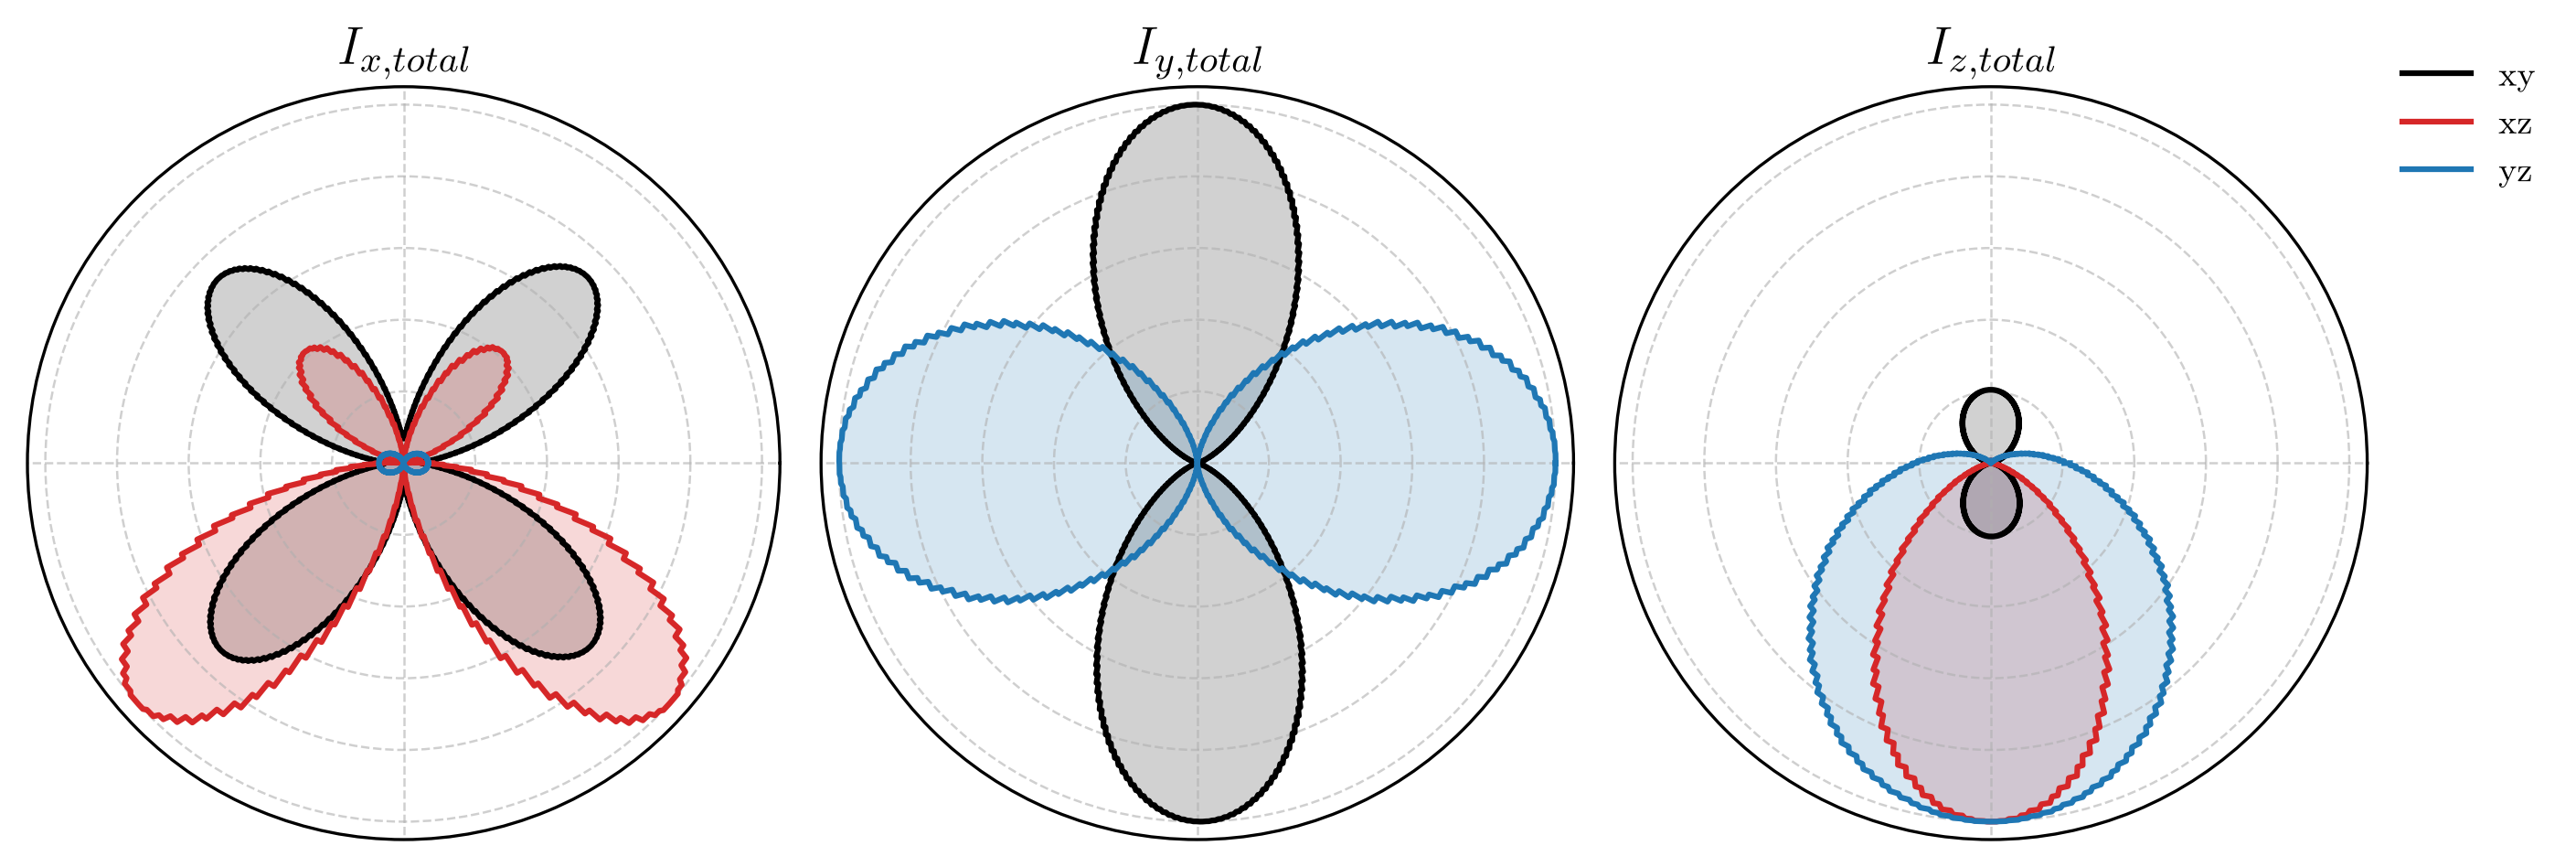

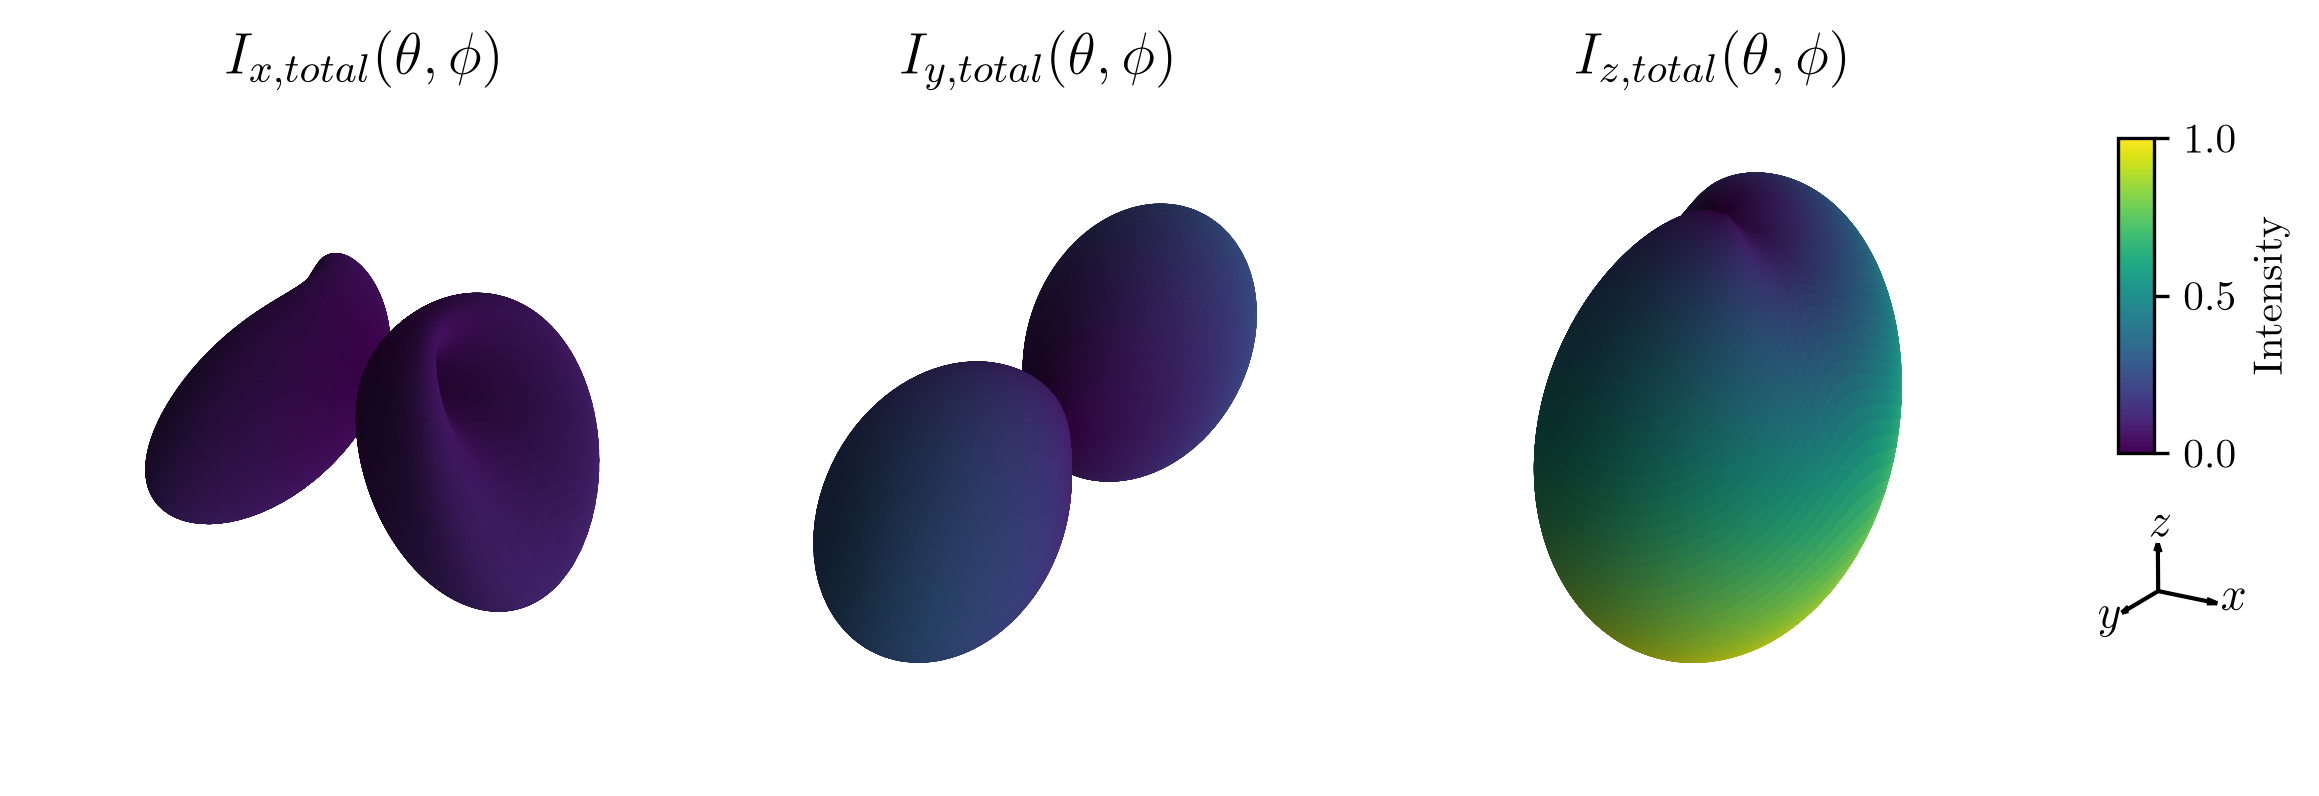

In [8]:
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_total_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, 
                     scale_list=[0.4, 0.24, 0.36], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_total_3d", results_dir=results_dir)